In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Read csv
csv_files = list(
    Path("../output/hourly_trip_counts_csv").glob("part-*.csv")
)

if not csv_files:
    raise FileNotFoundError(
        "시간대별 운행량 CSV 파일을 찾을 수 없습니다."
    )

hourly_df = pd.read_csv(csv_files[0])
hourly_df = hourly_df.sort_values("pickup_hour")

hourly_df

,pickup_hour,trip_count
0,0,98189
1,1,65477
2,2,44513
3,3,32174
4,4,27240
5,5,30589
6,6,59861
7,7,102958
8,8,134050
9,9,136442


In [ ]:
# find peak hour
peak_row = hourly_df.loc[hourly_df["trip_count"].idxmax()]

peak_hour = int(peak_row["pickup_hour"])
peak_trip_count = int(peak_row["trip_count"])

print(f"피크 시간대: {peak_hour}시")
print(f"운행 건수: {peak_trip_count:,}건")

피크 시간대: 18시
운행 건수: 221,377건


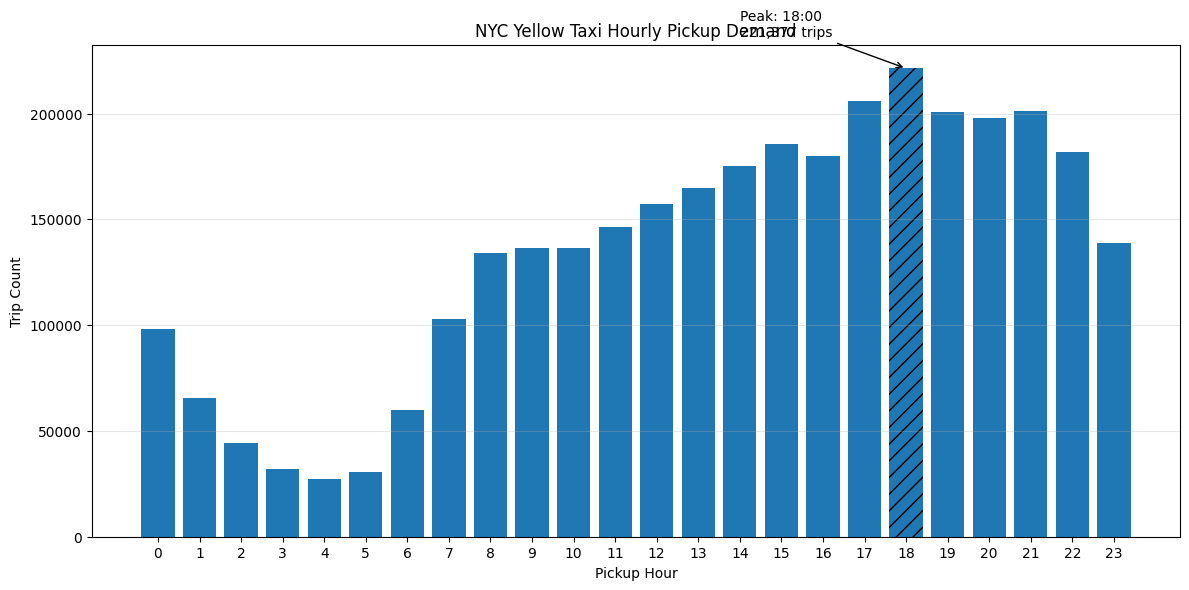

In [6]:
plt.figure(figsize=(12, 6))

bars = plt.bar(
    hourly_df["pickup_hour"],
    hourly_df["trip_count"],
)

bars[peak_hour].set_hatch("//")

plt.title("NYC Yellow Taxi Hourly Pickup Demand")
plt.xlabel("Pickup Hour")
plt.ylabel("Trip Count")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.annotate(
    f"Peak: {peak_hour}:00\n{peak_trip_count:,} trips",
    xy=(peak_hour, peak_trip_count),
    xytext=(peak_hour - 4, peak_trip_count + 15000),
    arrowprops={"arrowstyle": "->"},
)

plt.tight_layout()
output_path = Path("../output/figures")
output_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_path / "hourly_trip_demand.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [8]:
weather_csv_files = list(
    Path("../output/taxi_weather_hourly_csv").glob("part-*.csv")
)

if not weather_csv_files:
    raise FileNotFoundError(
        "택시·날씨 결합 CSV 파일을 찾을 수 없습니다."
    )

taxi_weather_df = pd.read_csv(weather_csv_files[0])

taxi_weather_df["pickup_hour"] = pd.to_datetime(
    taxi_weather_df["pickup_hour"]
)

taxi_weather_df.head()

,pickup_hour,trip_count,temperature_2m,precipitation
0,2026-02-01 00:00:00-05:00,7958,-11.3,0.0
1,2026-02-01 01:00:00-05:00,6914,-11.8,0.0
2,2026-02-01 02:00:00-05:00,4620,-11.1,0.0
3,2026-02-01 03:00:00-05:00,3280,-11.8,0.0
4,2026-02-01 04:00:00-05:00,2199,-12.2,0.0


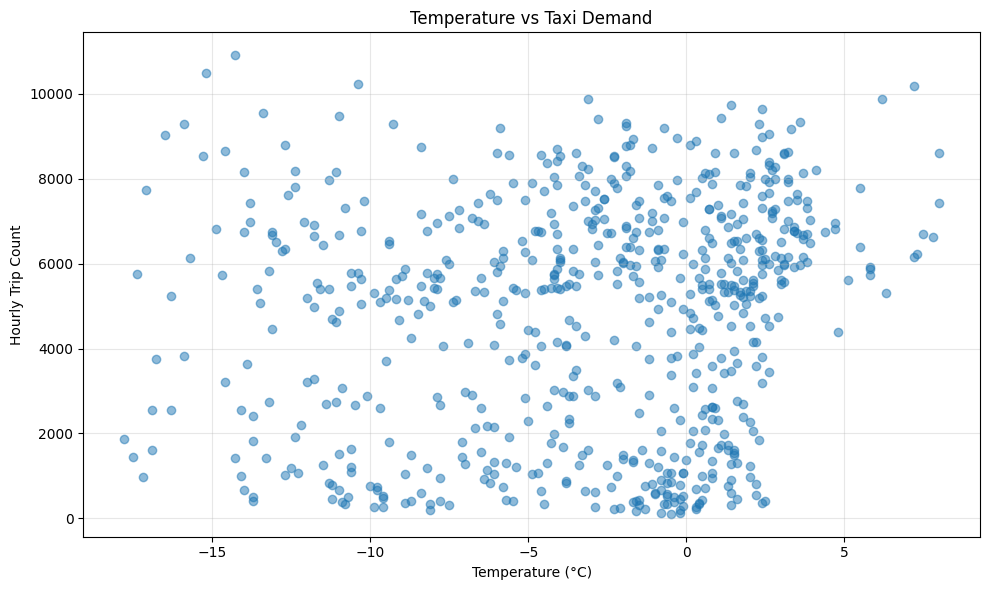

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(
    taxi_weather_df["temperature_2m"],
    taxi_weather_df["trip_count"],
    alpha=0.5,
)

plt.title("Temperature vs Taxi Demand")
plt.xlabel("Temperature (°C)")
plt.ylabel("Hourly Trip Count")
plt.grid(alpha=0.3)
plt.tight_layout()

figure_dir = Path("../output/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figure_dir / "temperature_vs_taxi_demand.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


### 기온과 택시 수요

기온과 시간당 택시 수요의 상관계수는 0.1362로 나타났다.

산점도에서도 기온이 높아질수록 수요가 약간 증가하는 경향은 보이지만,
점들이 넓게 퍼져 있어 강한 선형 관계는 확인되지 않는다.

In [10]:
taxi_weather_df["rain_condition"] = (
    taxi_weather_df["precipitation"]
    .gt(0)
    .map({
        True: "Rain",
        False: "No Rain",
    })
)

rain_summary_df = (
    taxi_weather_df
    .groupby("rain_condition", as_index=False)
    .agg(
        average_trip_count=("trip_count", "mean"),
        hour_count=("trip_count", "count"),
    )
)

rain_summary_df

,rain_condition,average_trip_count,hour_count
0,No Rain,4960.966159,591
1,Rain,3616.641975,81


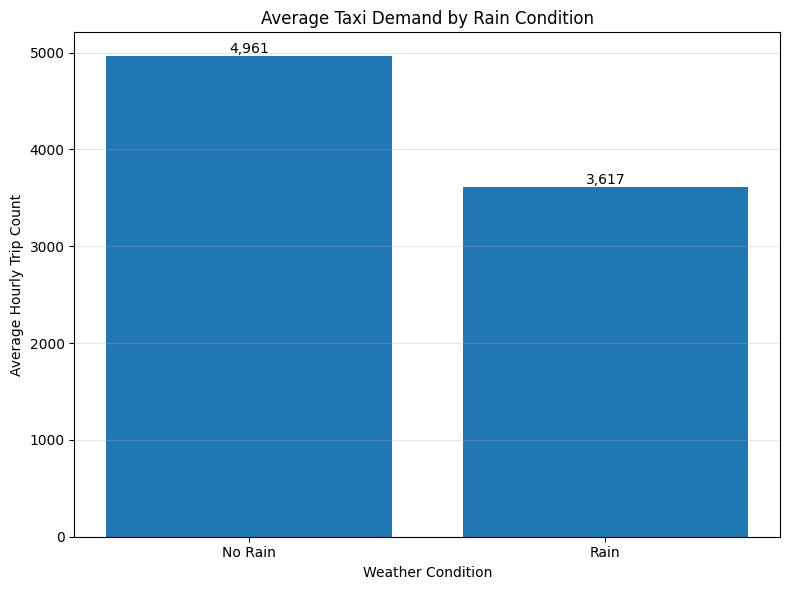

In [11]:
plt.figure(figsize=(8, 6))

bars = plt.bar(
    rain_summary_df["rain_condition"],
    rain_summary_df["average_trip_count"],
)

plt.title("Average Taxi Demand by Rain Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Hourly Trip Count")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

plt.savefig(
    figure_dir / "average_demand_by_rain_condition.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 강수 여부에 따른 택시 수요

비가 오지 않은 시간대의 평균 택시 수요는 4,960.97건이었고,
비가 온 시간대의 평균 수요는 3,616.64건이었다.

비가 온 시간대의 평균 수요는 비가 오지 않은 시간대보다 약 27.1% 낮았다.

다만 비가 온 시간대가 특정 시간대나 요일에 집중되었을 가능성이 있으므로,
이 차이를 강수의 직접적인 영향으로 단정할 수는 없다.

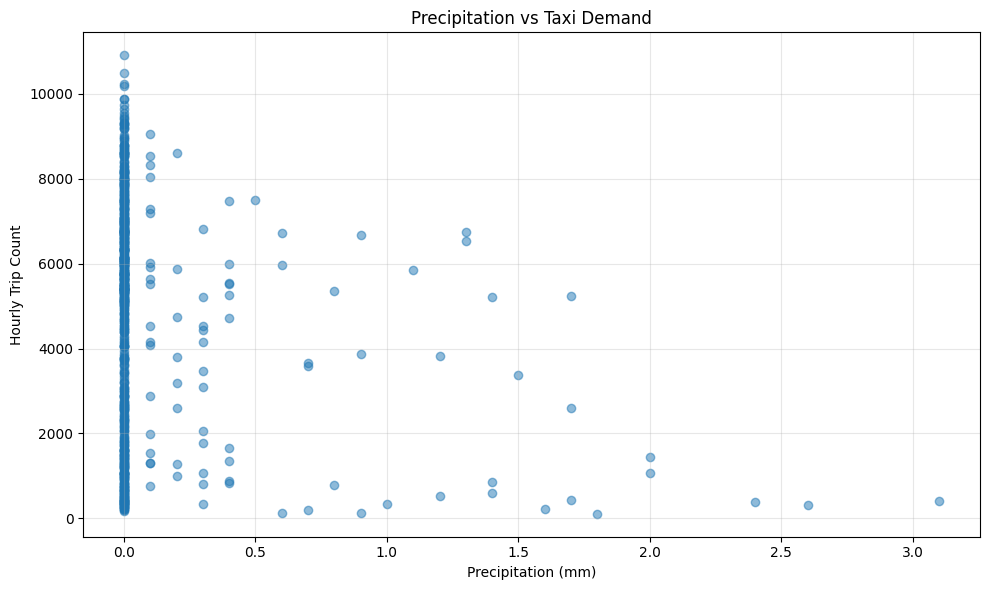

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    taxi_weather_df["precipitation"],
    taxi_weather_df["trip_count"],
    alpha=0.5,
)

plt.title("Precipitation vs Taxi Demand")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Hourly Trip Count")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figure_dir / "precipitation_vs_taxi_demand.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### 강수량과 택시 수요

강수량과 택시 수요의 상관계수는 -0.2004로,
약한 음의 상관관계를 보였다.

강수량이 증가할수록 시간당 택시 승차 건수가 감소하는 경향이 나타났지만,
관계가 강하지 않아 시간대와 요일 등의 추가 요인을 함께 고려해야 한다.